In [1]:
import pandas as pd
from pydataset import data
import numpy as np
df =data ('mtcars')

In [2]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
df.shape

(32, 11)

In [4]:
df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [5]:
df.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [6]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [7]:
df.isnull().sum()

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

In [8]:
df.isnull().values.any()

np.False_

In [9]:
df['mpg'].mean()

np.float64(20.090625000000003)

In [10]:
df['hp'].max()

335

In [11]:
df['wt'].min()

1.513

In [12]:
df['wt'].max()

5.424

In [13]:
df['cyl'].value_counts().sort_index()

cyl
4    11
6     7
8    14
Name: count, dtype: int64

In [14]:
df.groupby('cyl')['mpg'].mean()

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

In [15]:
df.groupby('am')['mpg'].mean()

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

In [16]:
df.groupby('gear')['mpg'].mean()

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

In [17]:
df.pivot_table(values='mpg',index='cyl',columns= 'am',aggfunc='mean')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [18]:
df ['efficiency']= 'low'
df.loc[df['mpg']>20,'efficiency']= 'high'

In [19]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,high
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,high
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,high
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,high
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,low


In [20]:
df['am']= df['am'].map({0:'Automatic',1:'Manual'})

In [21]:
df['vs']=df['vs'].map({0:'v-shaped',1:'Straight'})

In [22]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,v-shaped,Manual,4,4,high
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,v-shaped,Manual,4,4,high
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,high
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,high
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,v-shaped,Automatic,3,2,low


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

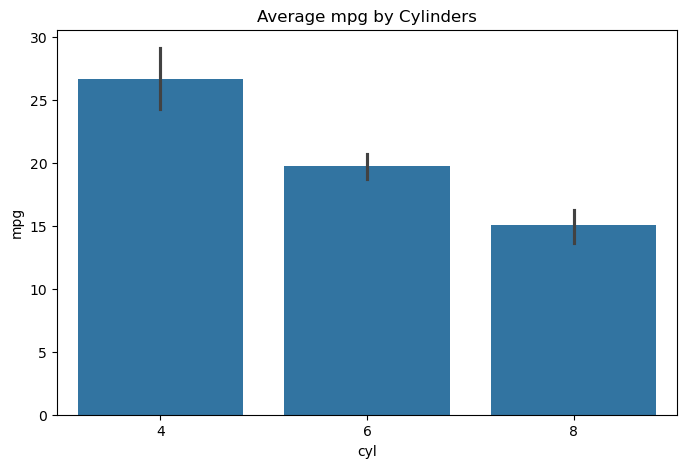

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x='cyl', y='mpg', data= df)
plt.title('Average mpg by Cylinders')
plt.show()

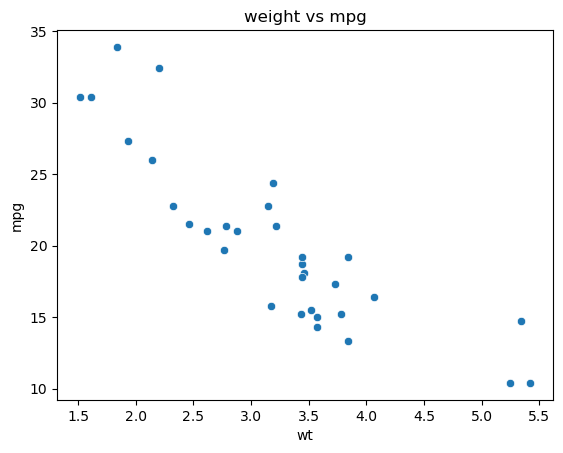

In [25]:
sns.scatterplot(x='wt', y='mpg', data=df)
plt.title('weight vs mpg')
plt.show()

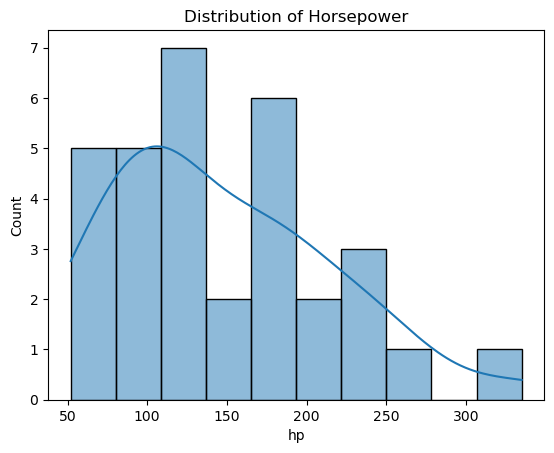

In [26]:
sns.histplot(df['hp'], bins=10, kde=True)
plt.title('Distribution of Horsepower')
plt.show()

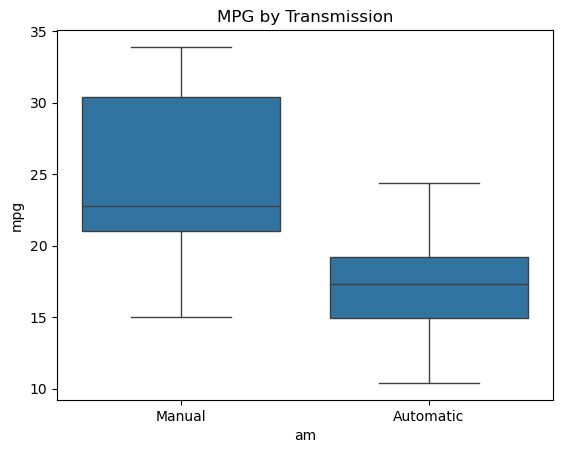

In [27]:
sns.boxplot(x='am', y='mpg', data=df)
plt.title ('MPG by Transmission')
plt.show()